<a href="https://colab.research.google.com/github/mohammedh897/chicago_crime_analysis/blob/main/Project_3_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Analysis (2001–2022)
### Project 3 — Part 1 | Time Series & EDA
---
**Dataset:** 7,713,109 crime records across 22 years from the Chicago Data Portal  
**Goal:** Answer stakeholder questions for a local newspaper reporter on crime trends, patterns, and cycles.


## Step 0 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import holidays
import glob, os, zipfile, warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (13, 5), 'axes.titlesize': 13})
print("Libraries loaded.")


Libraries loaded.


## Step 1 — Load & Merge All 22 CSV Files

In [ ]:
import gdown, zipfile, os, glob
import pandas as pd

GDRIVE_LINK = "https://drive.google.com/uc?id=1avxUlCAros-R9GF6SKXqM_GopzO7VwA5"

gdown.download(GDRIVE_LINK, "chicago_crimes.zip", quiet=False, fuzzy=True)

with zipfile.ZipFile("chicago_crimes.zip", "r") as z:
    csv_names = sorted([n for n in z.namelist() if n.endswith(".csv")])
    print(f"Found {len(csv_names)} CSV files inside zip")

    chunks = []
    for name in csv_names:
        with z.open(name) as f:
            df_yr = pd.read_csv(f, low_memory=False)
            chunks.append(df_yr)
        print(f"  Loaded {os.path.basename(name)}: {len(df_yr):,} rows")

df_raw = pd.concat(chunks, ignore_index=True)
print(f"\nTotal rows loaded: {len(df_raw):,}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Downloading...
From (original): https://drive.google.com/uc?id=1avxUlCAros-R9GF6SKXqM_GopzO7VwA5
From (redirected): https://drive.google.com/uc?id=1avxUlCAros-R9GF6SKXqM_GopzO7VwA5&confirm=t&uuid=840f590f-7bc1-46b7-b0c0-435e8f0dd3c0
To: /content/chicago_crimes.zip
100%|██████████| 196M/196M [00:00<00:00, 203MB/s]


Found 22 CSV files inside zip
  Loaded Chicago-Crime_2001.csv: 485,886 rows
  Loaded Chicago-Crime_2002.csv: 486,807 rows
  Loaded Chicago-Crime_2003.csv: 475,985 rows
  Loaded Chicago-Crime_2004.csv: 469,422 rows
  Loaded Chicago-Crime_2005.csv: 453,773 rows
  Loaded Chicago-Crime_2006.csv: 448,179 rows
  Loaded Chicago-Crime_2007.csv: 437,087 rows
  Loaded Chicago-Crime_2008.csv: 427,183 rows
  Loaded Chicago-Crime_2009.csv: 392,827 rows
  Loaded Chicago-Crime_2010.csv: 370,513 rows
  Loaded Chicago-Crime_2011.csv: 351,993 rows
  Loaded Chicago-Crime_2012.csv: 336,319 rows
  Loaded Chicago-Crime_2013.csv: 307,536 rows
  Loaded Chicago-Crime_2014.csv: 275,789 rows
  Loaded Chicago-Crime_2015.csv: 264,787 rows
  Loaded Chicago-Crime_2016.csv: 269,823 rows
  Loaded Chicago-Crime_2017.csv: 269,100 rows
  Loaded Chicago-Crime_2018.csv: 268,899 rows
  Loaded Chicago-Crime_2019.csv: 261,325 rows
  Loaded Chicago-Crime_2020.csv: 212,194 rows
  Loaded Chicago-Crime_2021.csv: 208,824 rows
  Lo

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


## Step 2 — Clean & Prepare Data

In [ ]:
df = df_raw.copy()

# Parse datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
bad_dates = df['Date'].isna().sum()
print(f"Unparseable dates dropped: {bad_dates}")
df = df.dropna(subset=['Date'])

# Set datetime index, sort
df = df.set_index('Date').sort_index()

# Engineer features
df['Year']      = df.index.year
df['Month']     = df.index.month
df['Hour']      = df.index.hour
df['date_only'] = df.index.normalize()

# Standardise District
df['District'] = df['District'].fillna(0).astype(int)

print(f"\nCleaned shape: {df.shape}")
print(f"Date range: {df.index.min()} --> {df.index.max()}")
print(f"\nPrimary Type value counts (top 10):\n{df['Primary Type'].value_counts().head(10)}")


Unparseable dates dropped: 0

Cleaned shape: (7713109, 15)
Date range: 2001-01-01 00:00:00 --> 2022-12-31 23:55:00

Primary Type value counts (top 10):
Primary Type
THEFT                  1626992
BATTERY                1410889
CRIMINAL DAMAGE         878914
NARCOTICS               746155
ASSAULT                 501103
OTHER OFFENSE           479174
BURGLARY                422246
MOTOR VEHICLE THEFT     366586
DECEPTIVE PRACTICE      340958
ROBBERY                 289677
Name: count, dtype: int64


In [ ]:
# Form 1: individual rows  (df)  — already built above
# Form 2: daily crime counts
daily_counts = df.resample('D').size().rename('Crime_Count')
print(f"Daily series: {len(daily_counts):,} days  |  {daily_counts.index.min()} to {daily_counts.index.max()}")
daily_counts.head()


Daily series: 8,035 days  |  2001-01-01 00:00:00 to 2022-12-31 00:00:00


,Crime_Count
Date,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


---
## Topic 1 — Comparing Police Districts (2022)
**Q1:** Which district had the most crimes in 2022?  
**Q2:** Which district had the least (excluding District 0 = unknown)?


Most crimes  → District 8:  14,805 crimes
Least crimes → District 31: 15 crimes


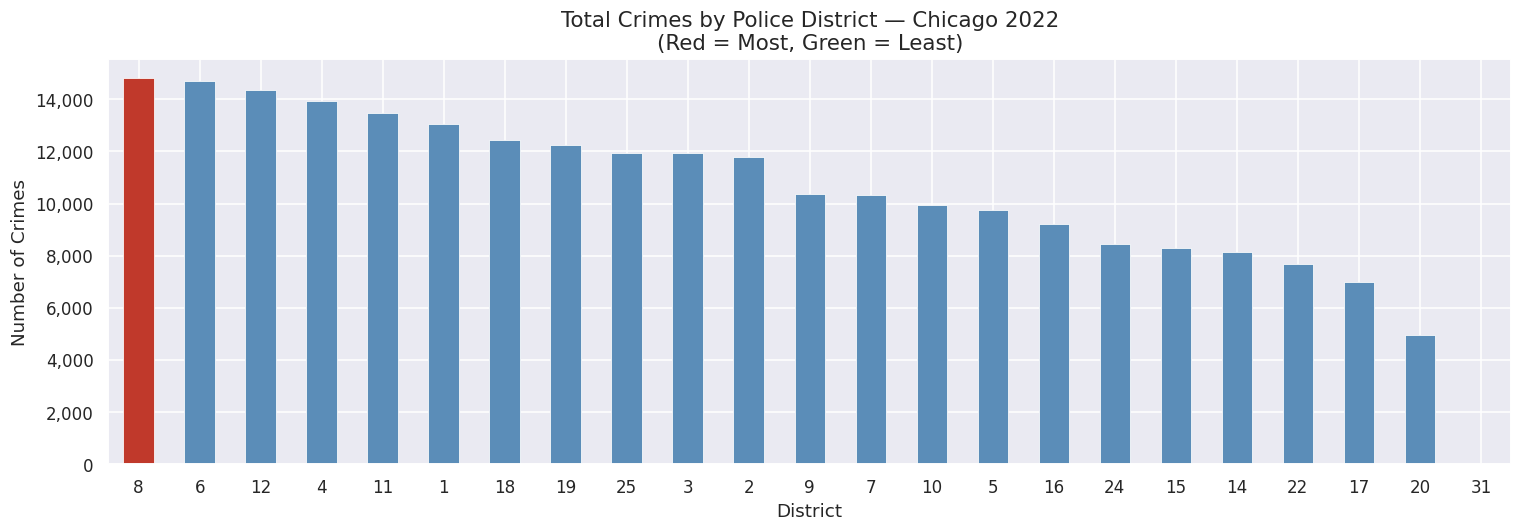

In [ ]:
df_2022 = df[df['Year'] == 2022]
dist_counts = (df_2022[df_2022['District'] > 0]
               .groupby('District')
               .size()
               .rename('Crimes')
               .sort_values(ascending=False))

most   = dist_counts.idxmax()
least  = dist_counts.idxmin()
print(f"Most crimes  → District {most}:  {dist_counts[most]:,} crimes")
print(f"Least crimes → District {least}: {dist_counts[least]:,} crimes")

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#c0392b' if d == most else '#27ae60' if d == least else '#5b8db8'
          for d in dist_counts.index]
dist_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title("Total Crimes by Police District — Chicago 2022\n(Red = Most, Green = Least)", fontsize=14)
ax.set_xlabel("District")
ax.set_ylabel("Number of Crimes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Top 5 and Bottom 5 for table clarity
top5    = dist_counts.head(5).reset_index()
bottom5 = dist_counts.tail(5).reset_index()
top5.columns = ['District', 'Crimes']
bottom5.columns = ['District', 'Crimes']
print("Top 5 Districts (2022)")
print(top5.to_string(index=False))
print("\nBottom 5 Districts (2022)")
print(bottom5.to_string(index=False))


Top 5 Districts (2022)
 District  Crimes
        8   14805
        6   14694
       12   14341
        4   13931
       11   13457

Bottom 5 Districts (2022)
 District  Crimes
       14    8158
       22    7671
       17    6997
       20    4960
       31      15


---
## Topic 2 — Crimes Across the Years
**Q1:** Is total crime increasing or decreasing over the years?  
**Q2:** Are any individual crime types moving in the *opposite* direction?


Year
2001    485886
2002    486807
2003    475985
2004    469422
2005    453773
2006    448179
2007    437087
2008    427183
2009    392827
2010    370513
2011    351993
2012    336319
2013    307536
2014    275789
2015    264787
2016    269823
2017    269100
2018    268899
2019    261325
2020    212194
2021    208824
2022    238858
Name: Total, dtype: int64


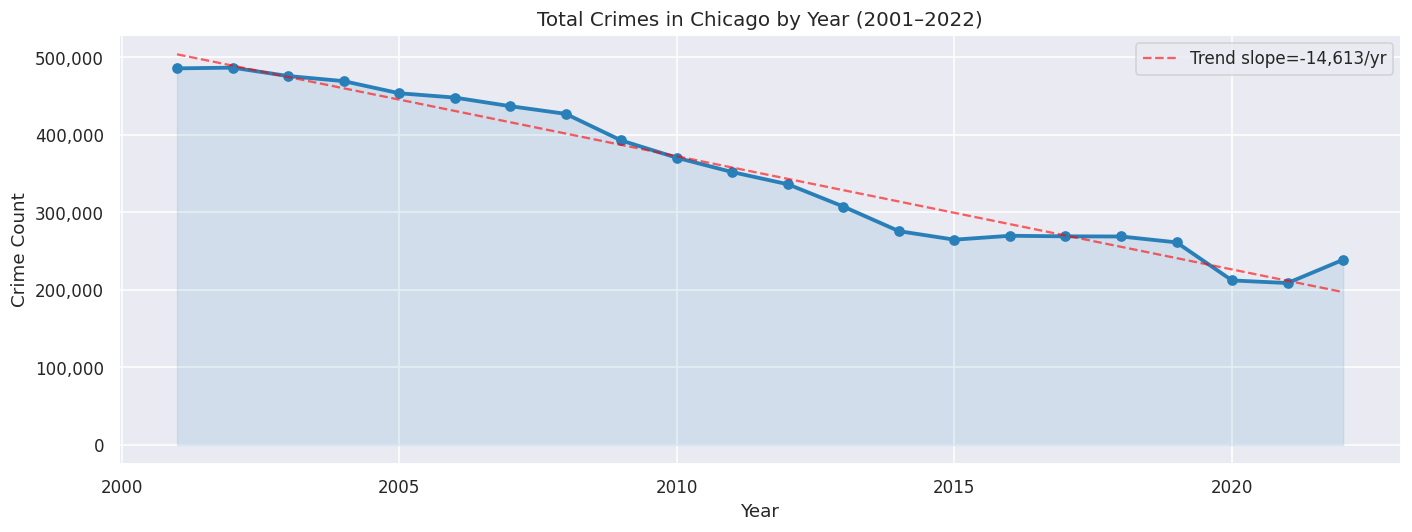


Overall change 2001 -> 2022: -50.8%


In [ ]:
yearly = df.groupby('Year').size().rename('Total')
print(yearly)

fig, ax = plt.subplots()
ax.plot(yearly.index, yearly.values, marker='o', color='#2980b9', linewidth=2.5, markersize=6)
ax.fill_between(yearly.index, yearly.values, alpha=0.12, color='#2980b9')
ax.set_title("Total Crimes in Chicago by Year (2001–2022)")
ax.set_xlabel("Year")
ax.set_ylabel("Crime Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
z = np.polyfit(yearly.index, yearly.values, 1)
ax.plot(yearly.index, np.poly1d(z)(yearly.index), '--', color='red', alpha=0.6, label=f'Trend slope={z[0]:+,.0f}/yr')
ax.legend()
plt.tight_layout()
plt.show()

pct_change = (yearly.iloc[-1] - yearly.iloc[0]) / yearly.iloc[0] * 100
print(f"\nOverall change 2001 -> 2022: {pct_change:.1f}%")


In [ ]:
# Counter-trend crimes: which types are INCREASING while total decreases?
type_yearly = df.groupby(['Year', 'Primary Type']).size().unstack(fill_value=0)

# Compute slope for each crime type
slopes = {}
for col in type_yearly.columns:
    z = np.polyfit(type_yearly.index, type_yearly[col], 1)
    slopes[col] = z[0]

slopes_s = pd.Series(slopes).sort_values(ascending=False)
overall_slope = np.polyfit(yearly.index, yearly.values, 1)[0]

print(f"Overall crime slope: {overall_slope:+,.0f} crimes/year  (DECREASING)")
print("\nCrime types with POSITIVE (increasing) slope:")
counter = slopes_s[slopes_s > 0]
print(counter.to_string())


Overall crime slope: -14,613 crimes/year  (DECREASING)

Crime types with POSITIVE (increasing) slope:
DECEPTIVE PRACTICE                   276.701299
WEAPONS VIOLATION                    170.457369
CRIMINAL SEXUAL ASSAULT               54.194805
INTERFERENCE WITH PUBLIC OFFICER      24.849238
CONCEALED CARRY LICENSE VIOLATION      9.083569
HOMICIDE                               8.574816
STALKING                               4.075663
OBSCENITY                              2.709204
NON-CRIMINAL                           0.993224
HUMAN TRAFFICKING                      0.731790
PUBLIC INDECENCY                       0.138340
NON - CRIMINAL                         0.137775
NON-CRIMINAL (SUBJECT SPECIFIED)       0.043478


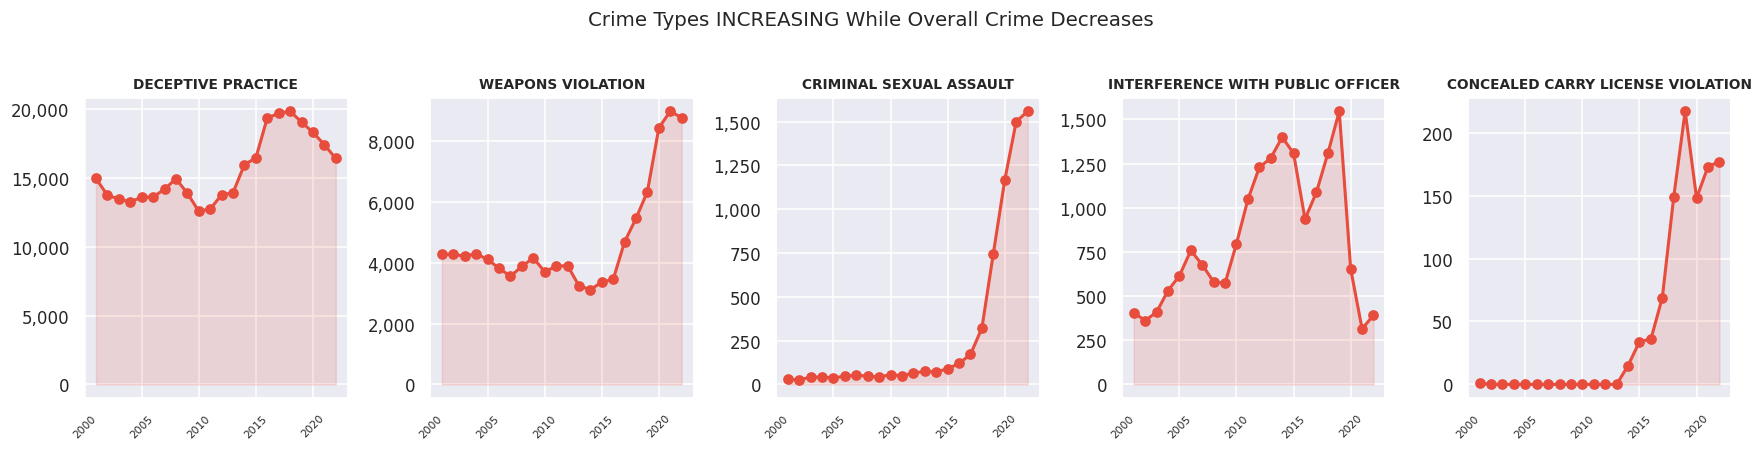

In [ ]:
# Plot top counter-trend types
top_counter = counter.nlargest(5).index.tolist()

fig, axes = plt.subplots(1, len(top_counter), figsize=(16, 4), sharey=False)
for ax, ctype in zip(axes, top_counter):
    series = type_yearly[ctype]
    ax.plot(series.index, series.values, marker='o', color='#e74c3c', linewidth=2)
    ax.fill_between(series.index, series.values, alpha=0.15, color='#e74c3c')
    ax.set_title(ctype, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Crime Types INCREASING While Overall Crime Decreases", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Topic 3 — AM vs PM Rush Hour
- **AM Rush:** 07:00 – 09:59  
- **PM Rush:** 16:00 – 18:59  

**Q1:** Which period has more total crimes?  
**Q2:** Top 5 crimes during each?  
**Q3:** Motor Vehicle Theft — AM or PM?


AM Rush total crimes: 770,651
PM Rush total crimes: 1,206,353

PM/AM ratio: 1.57x


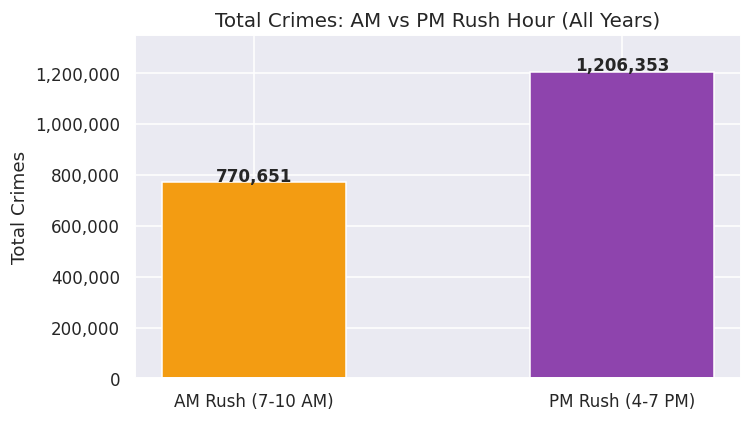

In [ ]:
am = df[df['Hour'].between(7, 9)]
pm = df[df['Hour'].between(16, 18)]

print(f"AM Rush total crimes: {len(am):,}")
print(f"PM Rush total crimes: {len(pm):,}")
print(f"\nPM/AM ratio: {len(pm)/len(am):.2f}x")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['AM Rush (7-10 AM)', 'PM Rush (4-7 PM)'],
       [len(am), len(pm)],
       color=['#f39c12', '#8e44ad'], edgecolor='white', width=0.5)
for i, v in enumerate([len(am), len(pm)]):
    ax.text(i, v + 5000, f"{v:,}", ha='center', fontsize=11, fontweight='bold')
ax.set_title("Total Crimes: AM vs PM Rush Hour (All Years)")
ax.set_ylabel("Total Crimes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, len(pm) * 1.12)
plt.tight_layout()
plt.show()


Top 5 crimes by period:
 Rank         AM Rush  AM Count         PM Rush  PM Count
    1           THEFT    185239           THEFT    293514
    2         BATTERY    108199         BATTERY    213002
    3 CRIMINAL DAMAGE     81281 CRIMINAL DAMAGE    134101
    4        BURGLARY     73999       NARCOTICS    103032
    5   OTHER OFFENSE     62453         ASSAULT     89600


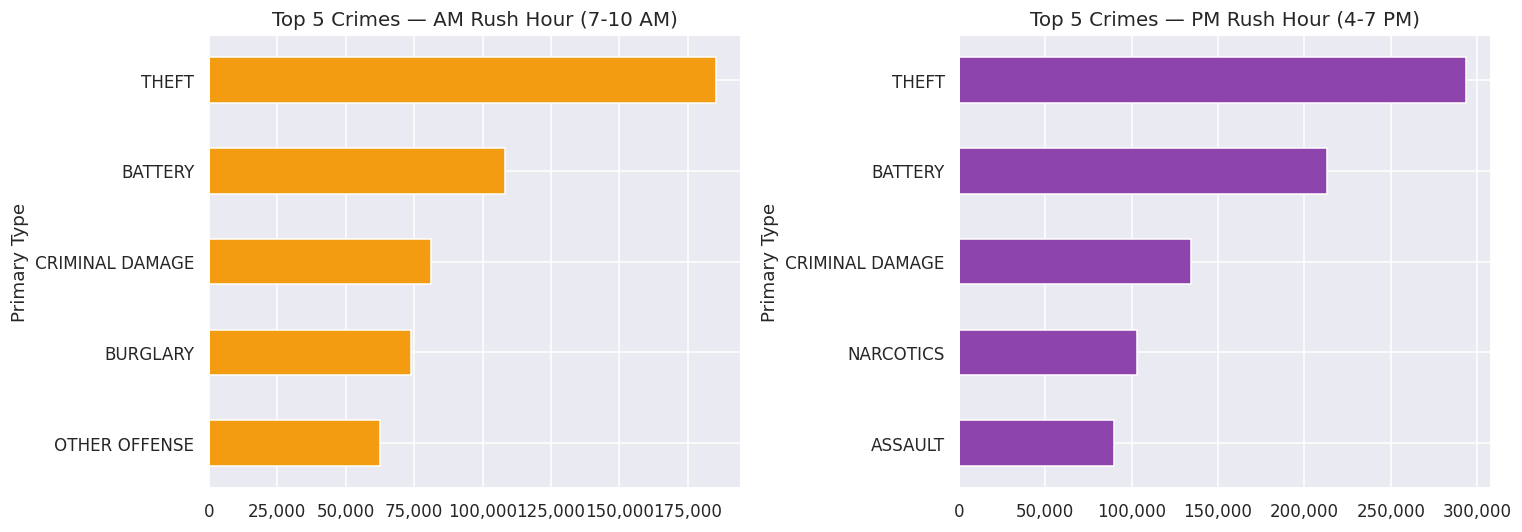

In [ ]:
# Top 5 crimes in each period
top5_am = am['Primary Type'].value_counts().head(5).rename('AM Rush')
top5_pm = pm['Primary Type'].value_counts().head(5).rename('PM Rush')

comparison = pd.DataFrame({'AM Rush': top5_am, 'PM Rush': top5_pm}).fillna(0).astype(int)
# Align on union index
all_types = sorted(set(top5_am.index) | set(top5_pm.index))
comp = pd.DataFrame({
    'AM Rush': am['Primary Type'].value_counts()[all_types],
    'PM Rush': pm['Primary Type'].value_counts()[all_types]
}).fillna(0).astype(int).sort_values('PM Rush', ascending=False)

print("Top 5 crimes by period:")
print(pd.DataFrame({'Rank': range(1,6),
                    'AM Rush': top5_am.index.tolist(),
                    'AM Count': top5_am.values,
                    'PM Rush': top5_pm.index.tolist(),
                    'PM Count': top5_pm.values}).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
top5_am.sort_values().plot(kind='barh', ax=ax1, color='#f39c12')
ax1.set_title("Top 5 Crimes — AM Rush Hour (7-10 AM)")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

top5_pm.sort_values().plot(kind='barh', ax=ax2, color='#8e44ad')
ax2.set_title("Top 5 Crimes — PM Rush Hour (4-7 PM)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


Motor Vehicle Theft — AM Rush: 41,578   PM Rush: 53,716
More common during: PM Rush


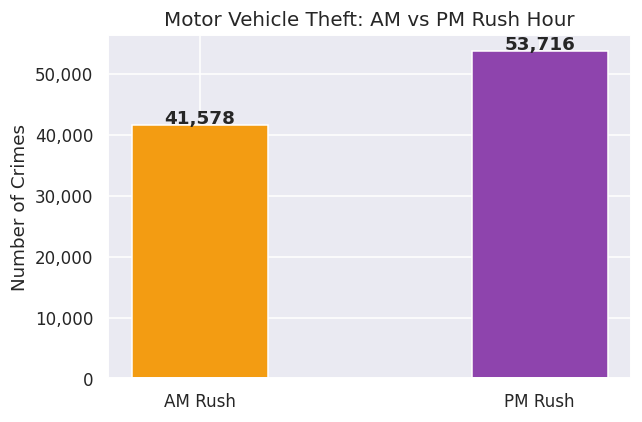

In [ ]:
# Motor Vehicle Theft
mvt_am = (am['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()
mvt_pm = (pm['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()
print(f"Motor Vehicle Theft — AM Rush: {mvt_am:,}   PM Rush: {mvt_pm:,}")
print(f"More common during: {'PM Rush' if mvt_pm > mvt_am else 'AM Rush'}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['AM Rush', 'PM Rush'], [mvt_am, mvt_pm],
       color=['#f39c12', '#8e44ad'], edgecolor='white', width=0.4)
for i, v in enumerate([mvt_am, mvt_pm]):
    ax.text(i, v + 200, f"{v:,}", ha='center', fontsize=12, fontweight='bold')
ax.set_title("Motor Vehicle Theft: AM vs PM Rush Hour")
ax.set_ylabel("Number of Crimes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


---
## Topic 4 — Comparing Months
**Q1:** What months have the most/least crime?  
**Q2:** Are there crime types that do NOT follow the overall seasonal pattern?


Month with most crime:  Jul (717,232)
Month with least crime: Feb (529,391)


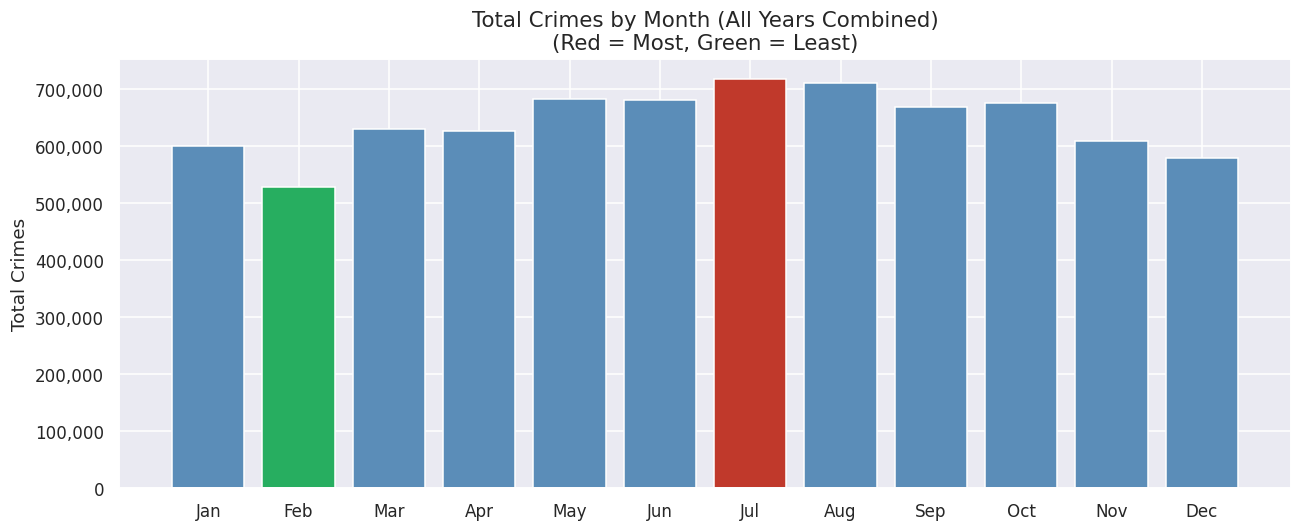

In [ ]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_total = df.groupby('Month').size().rename('Total')
monthly_total.index = month_names

print(f"Month with most crime:  {monthly_total.idxmax()} ({monthly_total.max():,})")
print(f"Month with least crime: {monthly_total.idxmin()} ({monthly_total.min():,})")

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#c0392b' if m == monthly_total.idxmax() else '#27ae60' if m == monthly_total.idxmin() else '#5b8db8'
          for m in month_names]
ax.bar(month_names, monthly_total.values, color=colors, edgecolor='white')
ax.set_title("Total Crimes by Month (All Years Combined)\n(Red = Most, Green = Least)", fontsize=14)
ax.set_ylabel("Total Crimes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


In [ ]:
type_month = df.groupby(['Month', 'Primary Type']).size().unstack(fill_value=0)
type_month.index = type_month.index.astype(int)  # ensure integer index

summer_months = [6, 7, 8]
winter_months = [12, 1, 2]

counter_seasonal = {}
for ctype in type_month.columns:
    summer_avg = type_month.loc[type_month.index.isin(summer_months), ctype].mean()
    winter_avg = type_month.loc[type_month.index.isin(winter_months), ctype].mean()
    if summer_avg == 0:
        continue
    ratio = winter_avg / summer_avg
    if ratio >= 0.85 and type_month[ctype].sum() > 500:
        counter_seasonal[ctype] = round(ratio, 2)

cs = pd.Series(counter_seasonal).sort_values(ascending=False)
print(f"Found {len(cs)} winter-leaning crime types:")
print(cs.to_string())

Found 9 winter-leaning crime types:
OFFENSE INVOLVING CHILDREN    1.05
OBSCENITY                     1.00
DECEPTIVE PRACTICE            1.00
NARCOTICS                     0.99
CRIMINAL TRESPASS             0.94
OTHER OFFENSE                 0.94
PROSTITUTION                  0.92
MOTOR VEHICLE THEFT           0.91
KIDNAPPING                    0.90


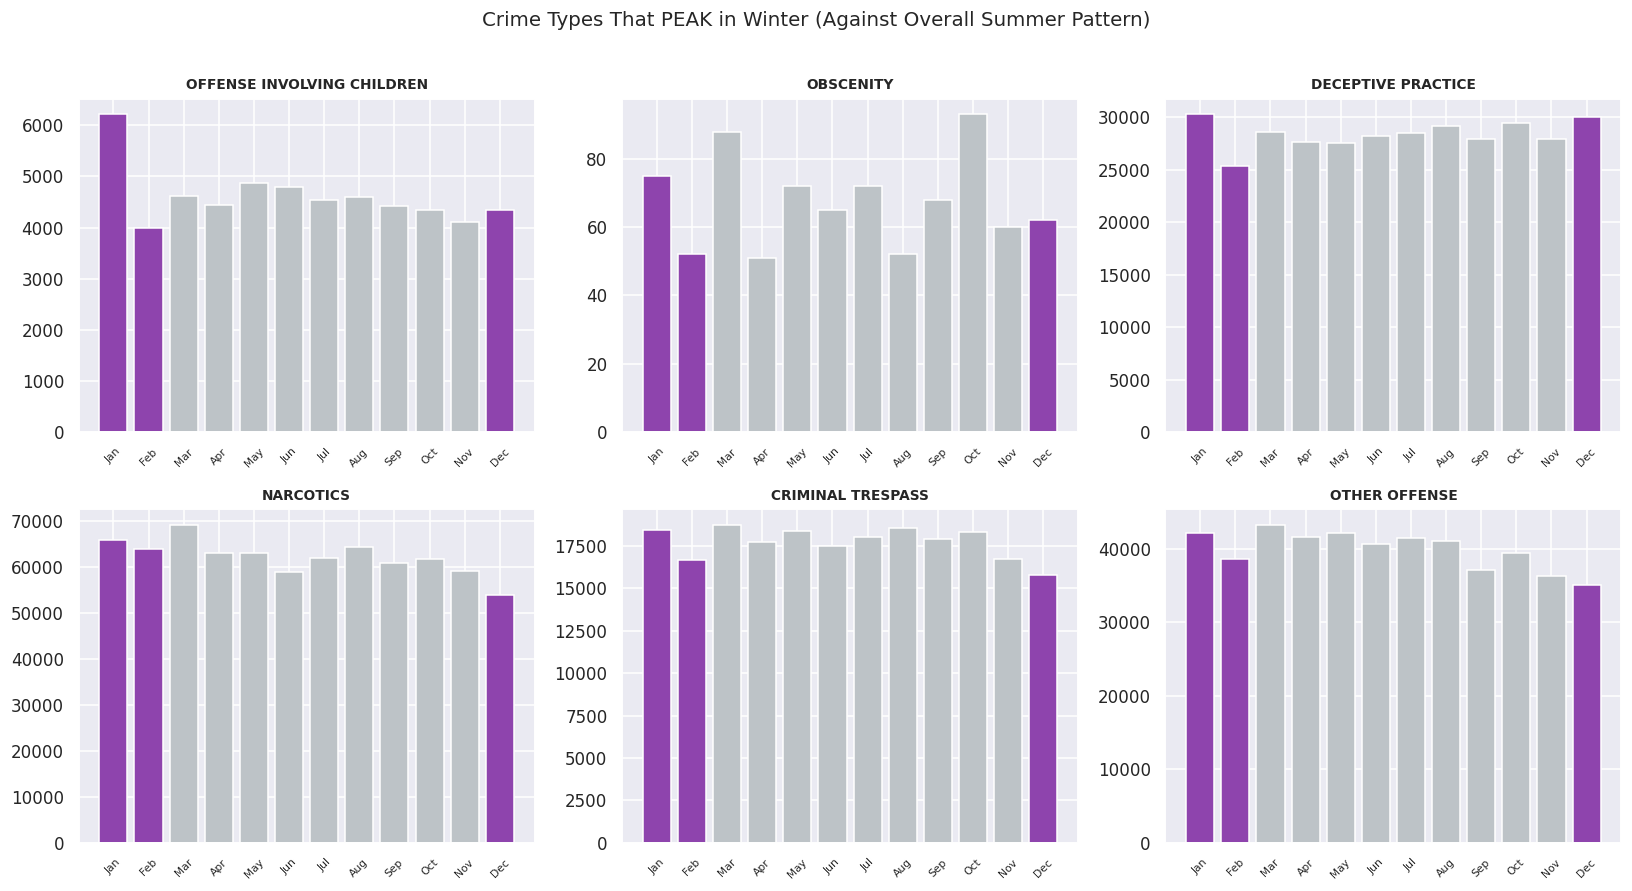

In [ ]:
# Visualise a few counter-seasonal types
top_cs = cs.nlargest(6).index.tolist()
n = len(top_cs)

cols = 3
rows = max(1, (n + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for ax, ctype in zip(axes, top_cs):
    series = type_month[ctype].copy()
    series.index = month_names
    ax.bar(month_names, series.values,
           color=['#8e44ad' if i in [11, 0, 1] else '#bdc3c7' for i in range(12)])
    ax.set_title(ctype, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Crime Types That PEAK in Winter (Against Overall Summer Pattern)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Topic 5 — Comparing Holidays
**Q1:** Top 3 holidays with the most crimes?  
**Q2:** For each of those top 3, what are the top 5 crimes on that day?


In [ ]:
# Build holiday lookup for all years in dataset
us_holidays = {}
for yr in range(2001, 2023):
    for date, name in holidays.US(state='IL', years=yr).items():
        us_holidays[date] = name

print(f"Total holiday-days in lookup: {len(us_holidays)}")
# Preview
list(us_holidays.items())[:8]


Total holiday-days in lookup: 307


[(datetime.date(2001, 1, 1), "New Year's Day"),
 (datetime.date(2001, 5, 28), 'Memorial Day'),
 (datetime.date(2001, 7, 4), 'Independence Day'),
 (datetime.date(2001, 9, 3), 'Labor Day'),
 (datetime.date(2001, 11, 22), 'Thanksgiving Day'),
 (datetime.date(2001, 12, 25), 'Christmas Day'),
 (datetime.date(2001, 1, 15), 'Martin Luther King Jr. Day'),
 (datetime.date(2001, 2, 19), "Washington's Birthday")]

In [ ]:
# Map each crime row to its holiday (if any)
df['holiday'] = df['date_only'].map(us_holidays)
holiday_crimes = df.dropna(subset=['holiday'])
print(f"Crimes on holidays: {len(holiday_crimes):,}")

# Total crimes per holiday NAME (aggregated across all years)
holiday_totals = holiday_crimes.groupby('holiday').size().sort_values(ascending=False)
top3_holidays  = holiday_totals.head(3)
print("\nTop 3 Holidays by Crime Count:")
print(top3_holidays.to_string())


Crimes on holidays: 275,929

Top 3 Holidays by Crime Count:
holiday
New Year's Day      32725
Independence Day    22672
Labor Day           22164


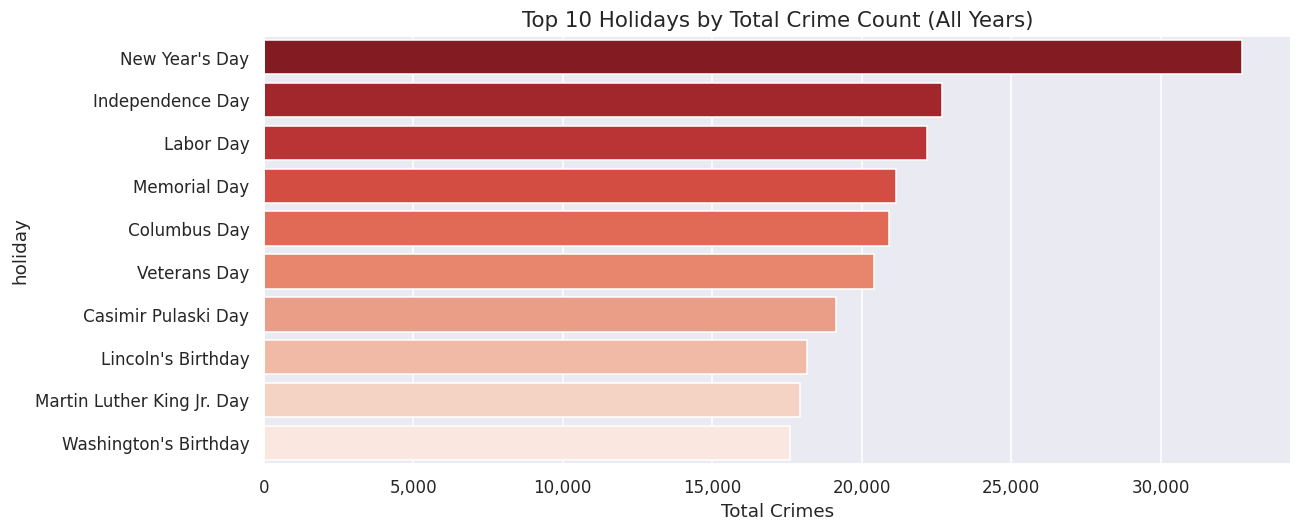

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
top10_h = holiday_totals.head(10)
sns.barplot(x=top10_h.values, y=top10_h.index, palette='Reds_r', ax=ax)
ax.set_title("Top 10 Holidays by Total Crime Count (All Years)", fontsize=14)
ax.set_xlabel("Total Crimes")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()



  New Year's Day  (total crimes: 32,725)
  1. THEFT                               6,845
  2. BATTERY                             6,043
  3. CRIMINAL DAMAGE                     3,236
  4. DECEPTIVE PRACTICE                  2,934
  5. OFFENSE INVOLVING CHILDREN          2,380

  Independence Day  (total crimes: 22,672)
  1. BATTERY                             5,805
  2. THEFT                               4,074
  3. CRIMINAL DAMAGE                     3,309
  4. ASSAULT                             1,547
  5. NARCOTICS                           1,522

  Labor Day  (total crimes: 22,164)
  1. BATTERY                             4,607
  2. THEFT                               4,520
  3. CRIMINAL DAMAGE                     2,475
  4. NARCOTICS                           2,078
  5. ASSAULT                             1,525


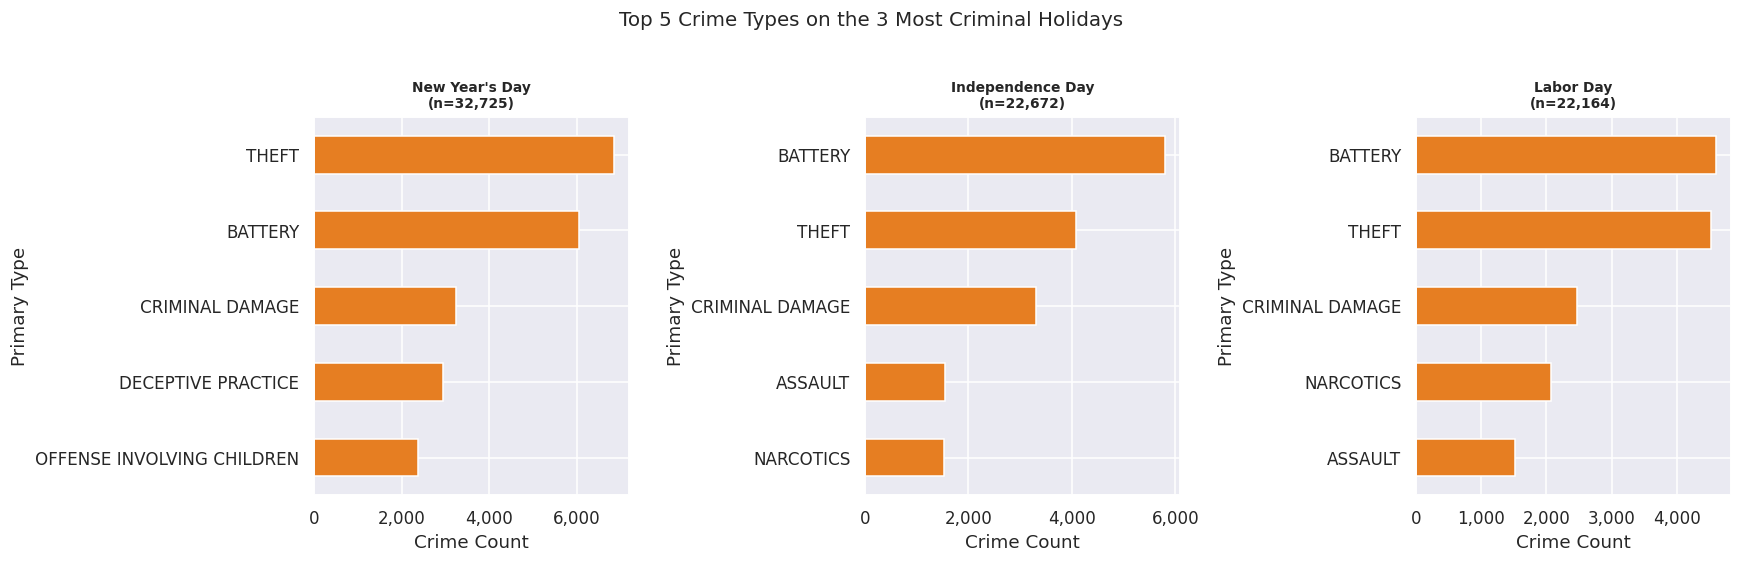

In [ ]:
# Top 5 crimes for each of the top 3 holidays
for holiday_name in top3_holidays.index:
    subset = holiday_crimes[holiday_crimes['holiday'] == holiday_name]
    top5   = subset['Primary Type'].value_counts().head(5)
    print(f"\n{'='*55}")
    print(f"  {holiday_name}  (total crimes: {len(subset):,})")
    print(f"{'='*55}")
    for rank, (crime, count) in enumerate(top5.items(), 1):
        print(f"  {rank}. {crime:<35} {count:,}")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, holiday_name in zip(axes, top3_holidays.index):
    subset = holiday_crimes[holiday_crimes['holiday'] == holiday_name]
    top5   = subset['Primary Type'].value_counts().head(5).sort_values()
    top5.plot(kind='barh', ax=ax, color='#e67e22', edgecolor='white')
    ax.set_title(f"{holiday_name}\n(n={len(subset):,})", fontsize=9, fontweight='bold')
    ax.set_xlabel("Crime Count")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.suptitle("Top 5 Crime Types on the 3 Most Criminal Holidays", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Topic 6 — Seasonality & Cycles (seasonal_decompose)
**Q1:** What seasonal cycles exist?  
**Q2:** How long is each cycle?  
**Q3:** What is the magnitude (min-to-max swing)?


Weekly series: 1148 weeks


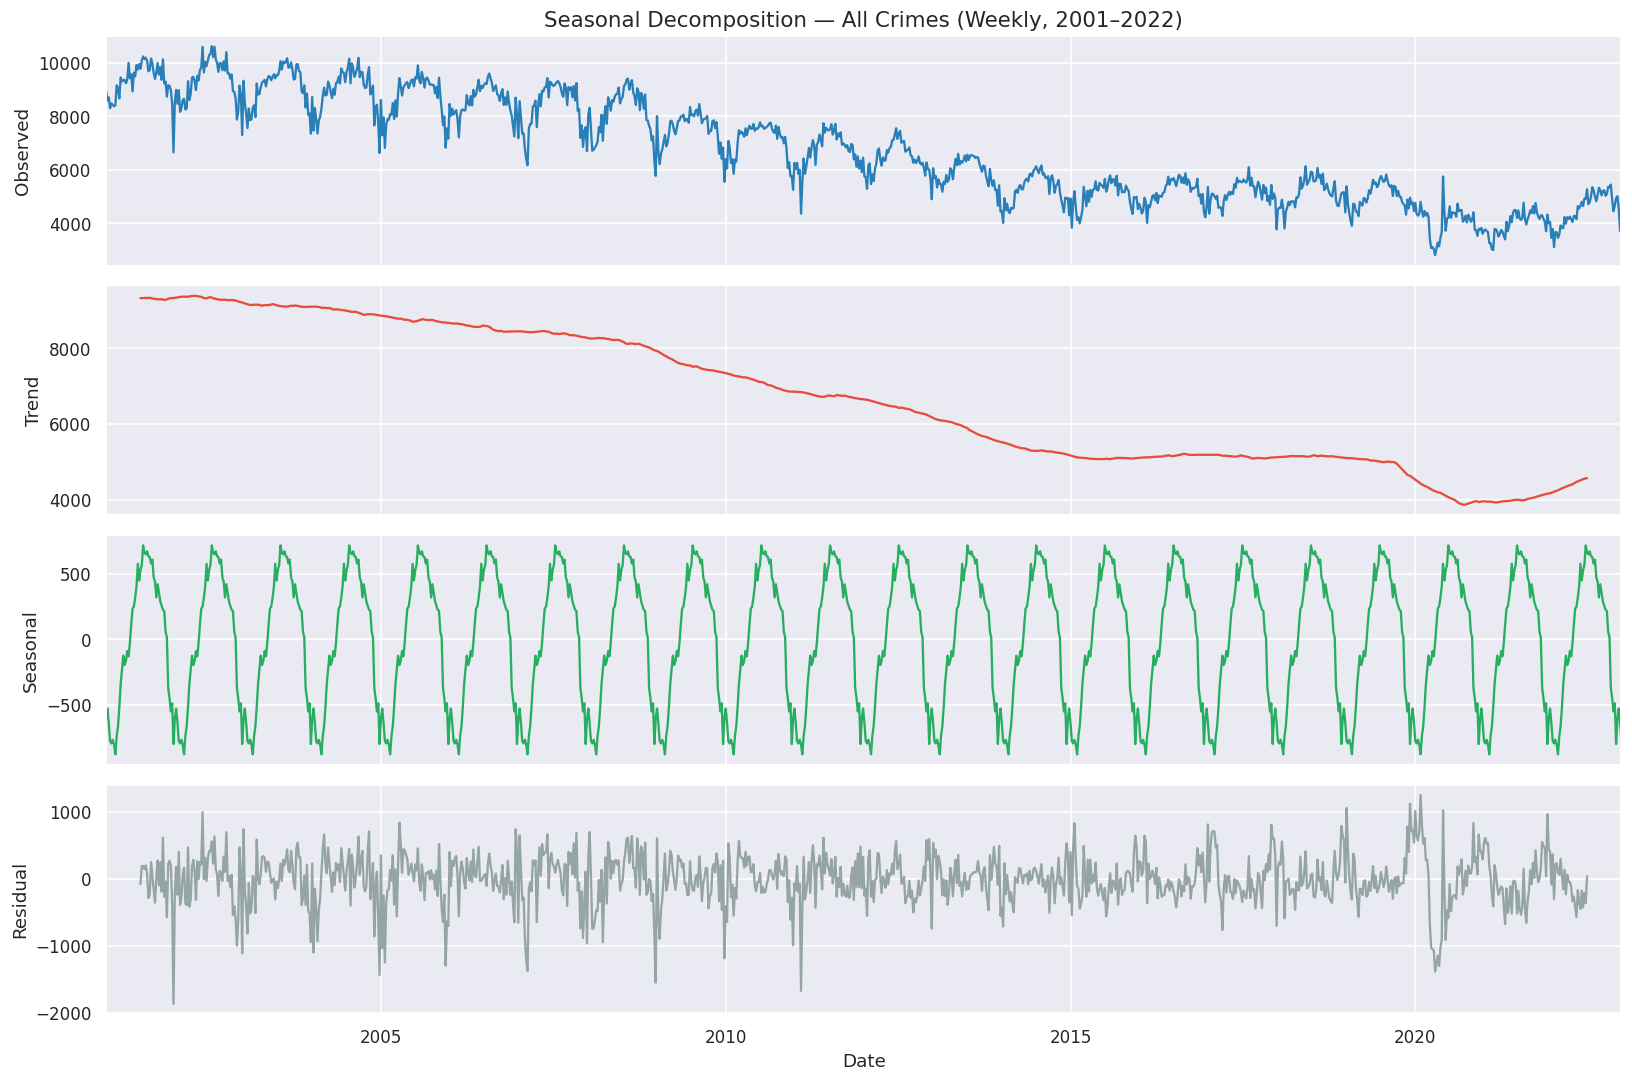


Cycle length:  ~52 weeks (~364 days / 1 year)
Seasonal magnitude (min-to-max swing): 1,599 crimes/week


In [ ]:
# --- 6a: All Crimes — Weekly resampling ---
weekly = daily_counts.resample('W').sum()
print(f"Weekly series: {len(weekly)} weeks")

decomp_all = seasonal_decompose(weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomp_all.observed.plot(ax=axes[0], color='#2980b9');  axes[0].set_ylabel('Observed')
decomp_all.trend.plot(ax=axes[1], color='#e74c3c');     axes[1].set_ylabel('Trend')
decomp_all.seasonal.plot(ax=axes[2], color='#27ae60');  axes[2].set_ylabel('Seasonal')
decomp_all.resid.plot(ax=axes[3], color='#95a5a6');     axes[3].set_ylabel('Residual')
axes[0].set_title("Seasonal Decomposition — All Crimes (Weekly, 2001–2022)", fontsize=14)
plt.tight_layout()
plt.show()

seasonal_range = decomp_all.seasonal.max() - decomp_all.seasonal.min()
print(f"\nCycle length:  ~52 weeks (~364 days / 1 year)")
print(f"Seasonal magnitude (min-to-max swing): {seasonal_range:,.0f} crimes/week")


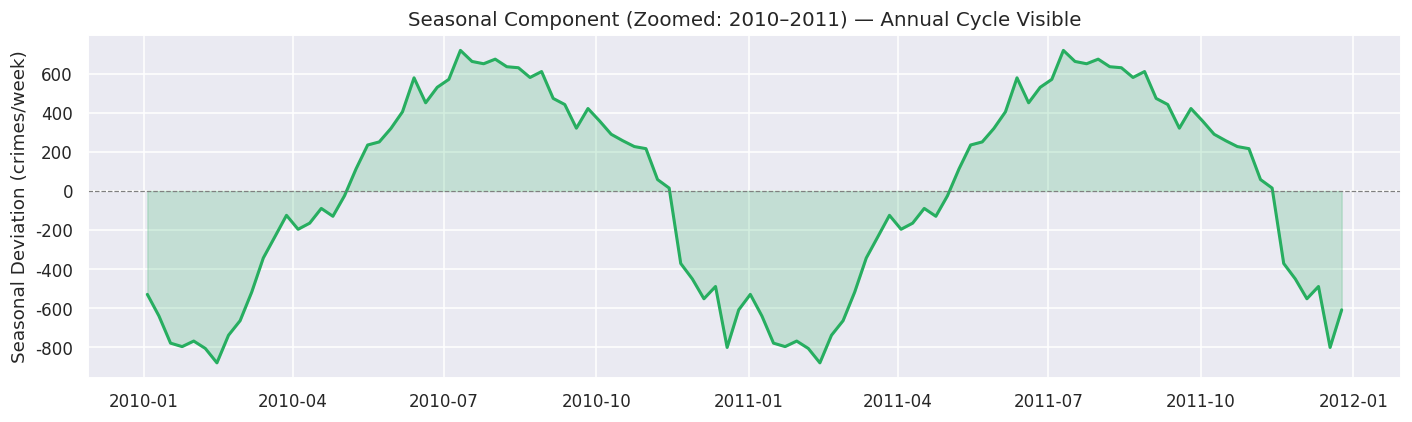

In [ ]:
# Zoom: one year to see the seasonal pattern clearly
zoom = decomp_all.seasonal['2010':'2011']
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(zoom.index, zoom.values, color='#27ae60', linewidth=2)
ax.fill_between(zoom.index, zoom.values, alpha=0.2, color='#27ae60')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title("Seasonal Component (Zoomed: 2010–2011) — Annual Cycle Visible", fontsize=13)
ax.set_ylabel("Seasonal Deviation (crimes/week)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


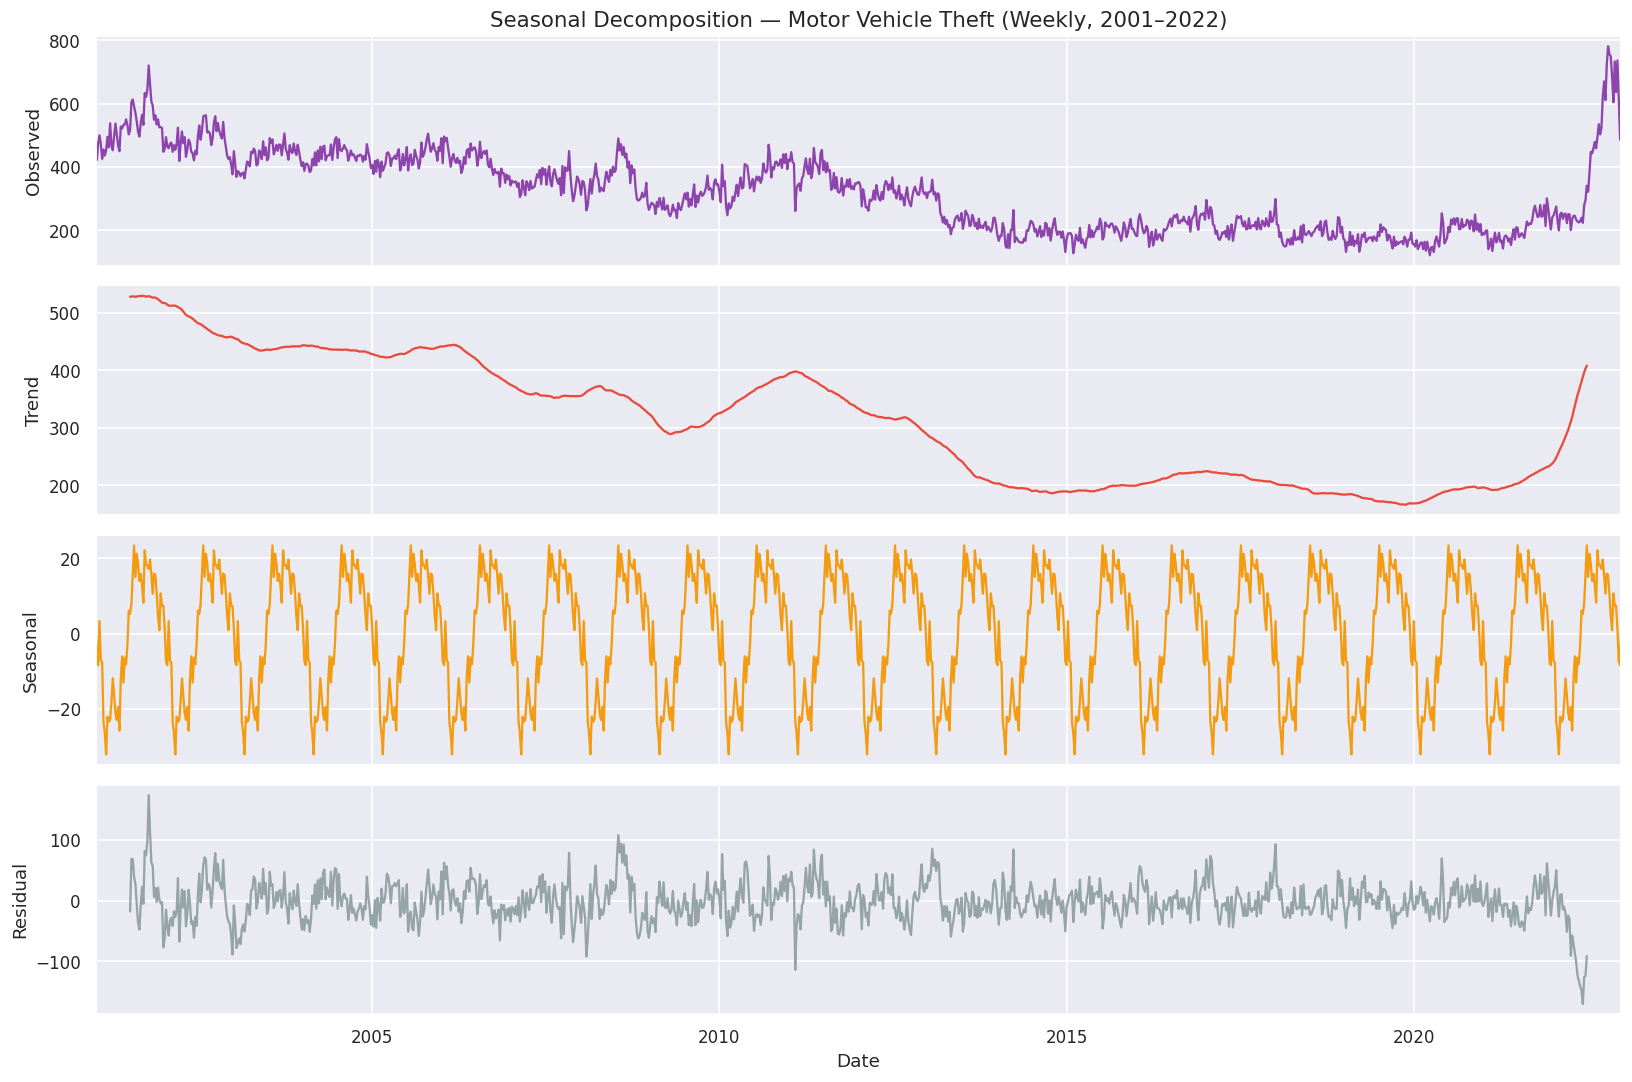

MVT Cycle length:  ~52 weeks (~1 year)
MVT Seasonal magnitude: 55.5 thefts/week


In [ ]:
# --- 6b: Motor Vehicle Theft — Weekly ---
mvt_daily  = df[df['Primary Type'] == 'MOTOR VEHICLE THEFT'].resample('D').size()
mvt_weekly = mvt_daily.resample('W').sum()

decomp_mvt = seasonal_decompose(mvt_weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomp_mvt.observed.plot(ax=axes[0], color='#8e44ad');  axes[0].set_ylabel('Observed')
decomp_mvt.trend.plot(ax=axes[1], color='#e74c3c');     axes[1].set_ylabel('Trend')
decomp_mvt.seasonal.plot(ax=axes[2], color='#f39c12');  axes[2].set_ylabel('Seasonal')
decomp_mvt.resid.plot(ax=axes[3], color='#95a5a6');     axes[3].set_ylabel('Residual')
axes[0].set_title("Seasonal Decomposition — Motor Vehicle Theft (Weekly, 2001–2022)", fontsize=14)
plt.tight_layout()
plt.show()

mvt_range = decomp_mvt.seasonal.max() - decomp_mvt.seasonal.min()
print(f"MVT Cycle length:  ~52 weeks (~1 year)")
print(f"MVT Seasonal magnitude: {mvt_range:,.1f} thefts/week")


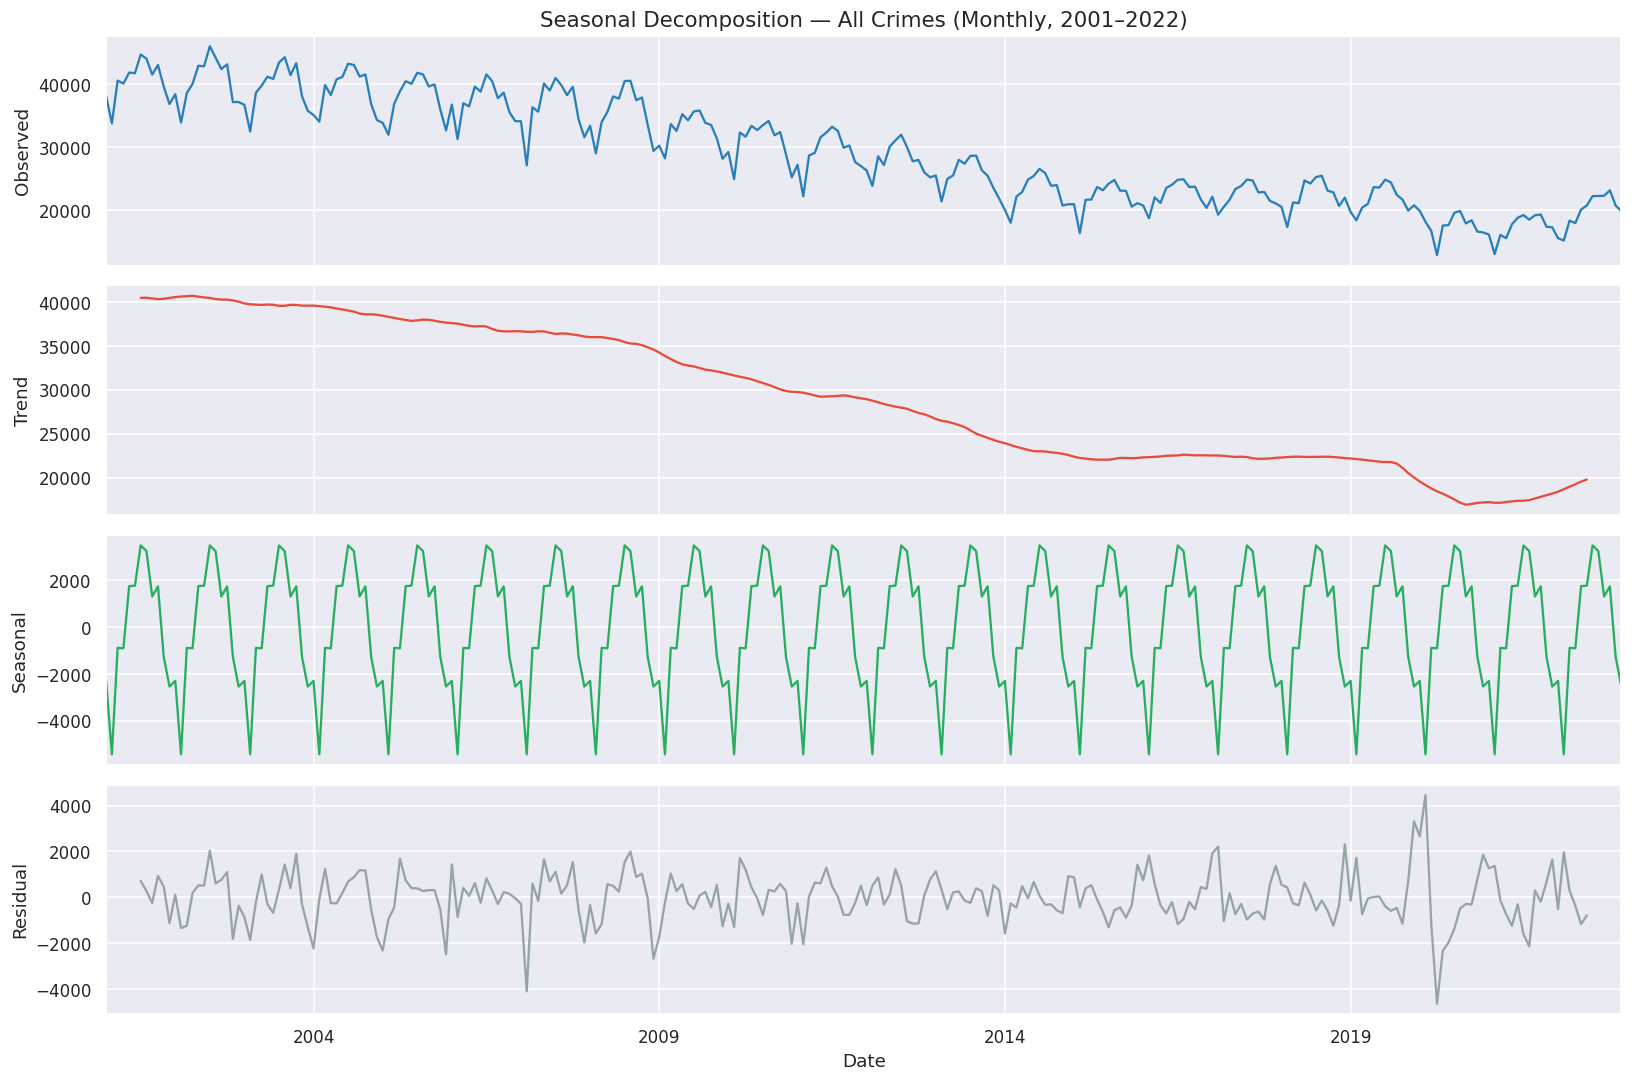

Monthly cycle length: 12 months (1 year)
Monthly seasonal magnitude: 8,898 crimes/month


In [ ]:
# --- 6c: Monthly resampling for long-run trend ---
monthly_ts = daily_counts.resample('ME').sum()
decomp_monthly = seasonal_decompose(monthly_ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomp_monthly.observed.plot(ax=axes[0], color='#2980b9');  axes[0].set_ylabel('Observed')
decomp_monthly.trend.plot(ax=axes[1], color='#e74c3c');     axes[1].set_ylabel('Trend')
decomp_monthly.seasonal.plot(ax=axes[2], color='#27ae60');  axes[2].set_ylabel('Seasonal')
decomp_monthly.resid.plot(ax=axes[3], color='#95a5a6');     axes[3].set_ylabel('Residual')
axes[0].set_title("Seasonal Decomposition — All Crimes (Monthly, 2001–2022)", fontsize=14)
plt.tight_layout()
plt.show()

monthly_range = decomp_monthly.seasonal.max() - decomp_monthly.seasonal.min()
print(f"Monthly cycle length: 12 months (1 year)")
print(f"Monthly seasonal magnitude: {monthly_range:,.0f} crimes/month")


---
## Summary of Key Findings

| Topic | Finding |
|---|---|
| **Districts** | District 8 had the most crimes in 2022; District 31 the fewest |
| **Yearly trend** | Overall crime declined ~50% from 2001 to 2022; Weapons Violation & Deceptive Practice are counter-trends (rising) |
| **Rush hour** | PM Rush has ~57% more total crimes than AM Rush; Motor Vehicle Theft also peaks in PM |
| **Monthly** | July peaks, February lowest. Winter peakers include Deceptive Practice and Narcotics |
| **Holidays** | Top 3 crime holidays are New Year's Day, Independence Day, and Labor Day. Theft tops New Year's Day, Battery tops the other two |
| **Seasonality** | Strong annual cycle (~364 days) in all-crime data; weekly swing ~1,600 crimes; MVT shows long decline then sharp recent rise |